# 04 — Prefill, decode và KV cache

Bảng phân rã thời gian trong README chia một lần trả lời thành hai pha của mô hình
ngôn ngữ: **prefill** và **sinh câu trả lời** (decode). Notebook này giải thích hai pha
đó khác nhau ở đâu, vì sao chúng bị giới hạn bởi **hai tài nguyên khác nhau** của GPU,
và vì sao điều đó quyết định kỹ thuật tối ưu nào có tác dụng với pha nào.

Nền tảng cần có: công thức attention (bạn đã vững). Các khái niệm mới — ký hiệu big-O,
KV cache, cường độ số học, mô hình roofline — được giảng từ đầu.

| Mục | Nội dung |
|---|---|
| 1 | Sinh chữ tự hồi quy và chi phí của cách làm ngây thơ |
| 2 | KV cache: vì sao được phép cache, và cache tốn bao nhiêu bộ nhớ |
| 3 | GPU có hai giới hạn: tốc độ tính và băng thông bộ nhớ |
| 4 | Cường độ số học và mô hình roofline |
| 5 | Dự đoán thời gian decode từ băng thông — và kiểm chứng |
| 6 | Hệ quả cho các đòn bẩy của dự án |

In [1]:
import math, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
plt.rcParams.update({"figure.figsize": (7, 3.4), "figure.dpi": 110})
dev = "cuda"
print(torch.cuda.get_device_name(0))

def timed(fn, warmup=3, reps=10):
    """Median time in ms, measured with CUDA events (notebook 02 explains why)."""
    for _ in range(warmup):
        fn()
    ts = []
    for _ in range(reps):
        s, e = torch.cuda.Event(True), torch.cuda.Event(True)
        torch.cuda.synchronize(); s.record(); fn(); e.record(); torch.cuda.synchronize()
        ts.append(s.elapsed_time(e))
    return float(np.median(ts))

NVIDIA RTX 1000 Ada Generation Laptop GPU


## 1. Sinh chữ tự hồi quy

Mô hình ngôn ngữ sinh chữ **từng token một**: token thứ $t+1$ được chọn từ phân phối
mà mô hình tính trên toàn bộ $t$ token trước đó, rồi được nối vào chuỗi để tính token
tiếp theo. Gọi là **tự hồi quy** (autoregressive).

Cách làm ngây thơ: mỗi bước, chạy lại **toàn bộ** chuỗi qua mô hình. Với lời nhắc dài
$n$ token và $m$ token cần sinh, tổng số lượt token đi qua mô hình là

$$n + (n+1) + \dots + (n+m-1) = mn + \frac{m(m-1)}{2}$$

Với $n = 1251$ (một ảnh + câu hỏi) và $m = 32$, đó là khoảng 40.000 lượt token — gấp
32 lần so với chỉ chạy lời nhắc một lần.

**Ký hiệu big-O.** Để nói chi phí *tăng theo* kích thước đầu vào ra sao mà không cần
hằng số chính xác, người ta viết $O(\cdot)$: $f(n) = O(g(n))$ nghĩa là khi $n$ đủ lớn,
$f(n)$ không vượt quá một hằng số nhân $g(n)$. Cách ngây thơ tốn $O(mn)$ lượt token;
riêng phần attention, vì mỗi token nhìn toàn bộ các token trước, còn tốn thêm
$O(mn^2)$ phép tính. Mục 2 hạ chi phí sinh xuống $O(m)$ lượt token.

**Ký hiệu mới**
- $n$: số token lời nhắc · $m$: số token sinh ra · $t$: vị trí token hiện tại
- $O(\cdot)$: bậc tăng trưởng, bỏ qua hằng số

## 2. KV cache

### 2.1. Vì sao được phép cache

Nhắc lại attention với mặt nạ nhân quả (causal mask): đầu ra ở vị trí $t$ là

$$o_t = \sum_{j \le t} \operatorname{softmax}_j\!\Big(\frac{q_t \cdot k_j}{\sqrt{d_h}}\Big)\, v_j,
\qquad q_t = x_t W_Q,\; k_j = x_j W_K,\; v_j = x_j W_V$$

Hai quan sát:
1. $k_j$ và $v_j$ chỉ phụ thuộc vào token $j$ (qua biểu diễn $x_j$ của nó ở lớp đó).
   Vì mặt nạ nhân quả, $x_j$ **không bao giờ thay đổi** khi có thêm token phía sau.
2. Để tính token mới ở vị trí $t$, ta chỉ cần $q_t$ **của riêng token đó**, cùng toàn
   bộ $k_j, v_j$ với $j \le t$.

Vậy: lưu lại $k_j, v_j$ của mọi token đã xử lý, ở **mọi lớp**. Mỗi bước sinh chỉ cần
đưa **một** token mới qua mô hình, tính $q, k, v$ của nó, nối $k, v$ vào bộ nhớ đệm,
và làm attention với toàn bộ bộ nhớ đệm. Bộ nhớ đệm này là **KV cache**.

Từ đó sinh chữ tách thành hai pha:
- **Prefill**: đưa cả $n$ token lời nhắc qua mô hình **một lần**, điền đầy KV cache,
  và lấy token đầu tiên.
- **Decode**: mỗi bước đưa **1** token qua mô hình, đọc KV cache.

**Ký hiệu mới**
- $q_t, k_j, v_j$: vector query, key, value · $W_Q, W_K, W_V$: ma trận chiếu
- $d_h$: số chiều của một head · $x_j$: biểu diễn của token $j$ tại lớp đang xét

Kiểm chứng trên mô hình thật: sinh cùng một câu trả lời có và không có KV cache. Kết
quả phải **giống hệt**, chỉ khác thời gian.

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from bench.harness import load_samples, PROMPT

MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()

sample = load_samples(1, seed=0)[0]
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
text = proc.apply_chat_template(msg, add_generation_prompt=True)
inputs = proc(text=text, images=[sample["image"]], return_tensors="pt").to(dev)
n_prompt = inputs["input_ids"].shape[1]
print("prompt tokens:", n_prompt)

M = 16
def gen(use_cache):
    return model.generate(**inputs, max_new_tokens=M, min_new_tokens=M,
                          do_sample=False, use_cache=use_cache)

with torch.no_grad():
    out_c = gen(True); out_n = gen(False)
    t_cache = timed(lambda: gen(True), warmup=1, reps=3)
    t_nocache = timed(lambda: gen(False), warmup=0, reps=1)

same = torch.equal(out_c, out_n)
print(f"identical tokens: {same}")
print(f"with KV cache   : {t_cache:7.0f} ms for {M} tokens")
print(f"without KV cache: {t_nocache:7.0f} ms for {M} tokens  ({t_nocache / t_cache:.1f}x slower)")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

prompt tokens: 1251


identical tokens: True
with KV cache   :    1192 ms for 16 tokens
without KV cache:   11243 ms for 16 tokens  (9.4x slower)


Kết quả giống hệt — KV cache là một phép tối ưu **chính xác**, không phải xấp xỉ.

(Không có cache, mỗi bước còn phải chạy lại cả bộ mã hoá thị giác, nên chênh lệch ở
đây còn lớn hơn một mô hình chỉ có chữ.)

### 2.2. KV cache tốn bao nhiêu bộ nhớ

Mỗi token lưu một vector key và một vector value ở mỗi lớp, mỗi head:

$$\text{byte mỗi token} = 2 \times L \times H_{kv} \times d_h \times b$$

**Ký hiệu mới**
- $L$: số lớp · $H_{kv}$: số head của key/value · $b$: số byte mỗi số (bf16: 2)
- Hệ số 2: một cho key, một cho value

**Về $H_{kv}$:** nhiều mô hình mới dùng **grouped-query attention** (GQA) — nhiều head
query dùng chung một head key/value, nên $H_{kv}$ nhỏ hơn số head query và KV cache
nhỏ đi tương ứng. Mô hình ngôn ngữ trong SmolVLM **không** dùng GQA ($H_{kv}$ bằng số
head query), nên cache của nó lớn hơn mức cần thiết.

In [3]:
tc = model.config.text_config
L, H, Hkv = tc.num_hidden_layers, tc.num_attention_heads, tc.num_key_value_heads
d_h = tc.hidden_size // H
per_token = 2 * L * Hkv * d_h * 2
print(f"L = {L}, heads = {H}, kv heads = {Hkv}, d_h = {d_h}")
print(f"formula: {per_token:,} bytes per token = {per_token / 1024:.0f} KiB")
print(f"formula for {n_prompt} prompt tokens: {per_token * n_prompt / 2**20:.0f} MiB")

with torch.no_grad():
    cache = model(**inputs, use_cache=True).past_key_values
measured = sum(t.numel() * t.element_size()
               for layer in cache.layers for t in (layer.keys, layer.values))
print(f"measured cache after prefill: {measured / 2**20:.0f} MiB")
del cache; torch.cuda.empty_cache()

L = 24, heads = 32, kv heads = 32, d_h = 64
formula: 196,608 bytes per token = 192 KiB
formula for 1251 prompt tokens: 235 MiB


measured cache after prefill: 235 MiB


Công thức khớp với cache đo được. Với một ảnh, cache khoảng 235 MiB — không đáng kể
trên máy 6 GB khi phục vụ một yêu cầu, nhưng nhân lên với nhiều yêu cầu đồng thời thì
nó mới là thứ chiếm bộ nhớ (xem notebook 06).

## 3. GPU có hai giới hạn

Một phép tính trên GPU cần hai thứ: **đọc dữ liệu** từ bộ nhớ (VRAM) vào các nhân tính,
và **tính**. Mỗi thứ có một tốc độ tối đa:

| Tài nguyên | Đơn vị | Ký hiệu |
|---|---|---|
| Tốc độ tính | FLOP/s (phép tính dấu phẩy động mỗi giây) | $F$ |
| Băng thông bộ nhớ | byte/s | $W$ |

Đo cả hai trên chính GPU này, bằng hai phép thử "thuần":
- Nhân hai ma trận vuông lớn: mỗi phần tử được dùng lại hàng nghìn lần, nên thời gian
  chỉ phụ thuộc tốc độ tính. Nhân ma trận $N \times N$ với $N \times N$ tốn $2N^3$ FLOP
  ($N^3$ phép nhân và $N^3$ phép cộng).
- Chép một mảng lớn: không tính gì, chỉ đọc rồi ghi, nên thời gian chỉ phụ thuộc băng
  thông. Chép $S$ byte là đọc $S$ và ghi $S$, tổng $2S$ byte.

**Ký hiệu mới**
- $F$: tốc độ tính đỉnh · $W$: băng thông bộ nhớ · FLOP: một phép cộng hoặc nhân số thực
- Lưu ý: $W$ ở đây là băng thông, khác $W_Q, W_K, W_V$ ở mục 2

In [4]:
N = 4096
a = torch.randn(N, N, device=dev, dtype=torch.bfloat16)
b = torch.randn(N, N, device=dev, dtype=torch.bfloat16)
t_mm = timed(lambda: a @ b, reps=20)
F = 2 * N ** 3 / (t_mm / 1e3)
del a, b

S = 256 * 2 ** 20                                     # 256 MiB
x = torch.empty(S // 2, device=dev, dtype=torch.bfloat16)
y = torch.empty_like(x)
t_cp = timed(lambda: y.copy_(x), reps=20)
BW = 2 * S / (t_cp / 1e3)
del x, y; torch.cuda.empty_cache()

print(f"compute  F  = {F / 1e12:5.1f} TFLOP/s (bf16 matmul)")
print(f"memory   W  = {BW / 1e9:5.0f} GB/s")
print(f"ridge point F / W = {F / BW:.0f} FLOP per byte")

compute  F  =  42.9 TFLOP/s (bf16 matmul)
memory   W  =   164 GB/s
ridge point F / W = 261 FLOP per byte


Con số cuối cùng quan trọng nhất. Trong thời gian GPU này đọc được **một byte** từ
bộ nhớ, nó tính được khoảng **260 FLOP**. Một phép tính làm ít hơn mức đó trên mỗi byte
đọc vào thì các nhân tính sẽ **ngồi chờ dữ liệu**.

## 4. Cường độ số học và mô hình roofline

**Cường độ số học** (arithmetic intensity) của một phép tính là số FLOP nó làm trên mỗi
byte phải đọc/ghi:

$$I = \frac{\text{FLOP}}{\text{byte}}$$

Thời gian tối thiểu của phép tính bị chặn bởi tài nguyên nào hết trước:

$$t \ge \max\Big(\frac{\text{FLOP}}{F},\; \frac{\text{byte}}{W}\Big)
\quad\Longleftrightarrow\quad
\text{hiệu năng đạt được} \le \min\big(F,\; I \times W\big)$$

Vẽ vế phải theo $I$ ta được **mô hình roofline**: một đường dốc ($I \times W$, vùng
**giới hạn bởi bộ nhớ** — memory-bound) gặp một mái bằng ($F$, vùng **giới hạn bởi tính
toán** — compute-bound), tại **điểm gãy** $I = F/W$.

**Áp vào một lớp tuyến tính** — thứ chiếm gần hết FLOP của Transformer. Nhân $T$ token
(ma trận $T \times d_{in}$) với ma trận trọng số $d_{in} \times d_{out}$ bf16:
- FLOP: $2\,T\,d_{in}\,d_{out}$
- byte: chủ yếu là trọng số, $2\,d_{in}\,d_{out}$ (khi $T$ nhỏ so với $d$)

$$I \approx \frac{2\,T\,d_{in}\,d_{out}}{2\,d_{in}\,d_{out}} = T$$

Cường độ số học **bằng số token xử lý cùng lúc**. Đây là mấu chốt của cả notebook:
- **Prefill**: $T = n \approx 1251$, vượt xa điểm gãy → **compute-bound**.
- **Decode**: $T = 1$ → cường độ khoảng 1 FLOP/byte, thấp hơn điểm gãy khoảng 260 lần
  → **memory-bound**. Mỗi bước decode phải đọc **toàn bộ trọng số** chỉ để làm một lượng
  tính nhỏ.

**Ký hiệu mới**
- $I$: cường độ số học · $T$: số token xử lý cùng lúc · $d_{in}, d_{out}$: kích thước lớp

Kiểm chứng: đo một lớp MLP thật của mô hình (2048 → 8192) với số token từ 1 đến 2048.

T =    1:   226.8 us   0.15 TFLOP/s
T =    2:   238.6 us   0.28 TFLOP/s
T =    4:   246.3 us   0.54 TFLOP/s
T =    8:   235.5 us   1.14 TFLOP/s
T =   16:   237.6 us   2.26 TFLOP/s
T =   32:   233.5 us   4.60 TFLOP/s
T =   64:   237.6 us   9.04 TFLOP/s
T =  128:   259.1 us  16.58 TFLOP/s
T =  256:   316.4 us  27.15 TFLOP/s
T =  512:   477.7 us  35.96 TFLOP/s
T = 1024:   901.6 us  38.11 TFLOP/s


T = 2048:  2680.3 us  25.64 TFLOP/s


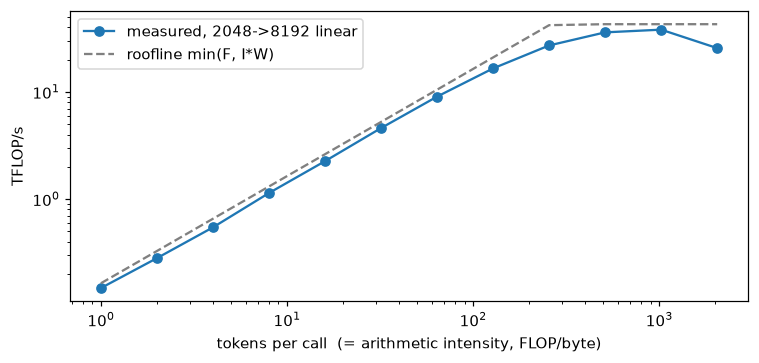

In [5]:
lin = model.model.text_model.layers[12].mlp.up_proj
d_in, d_out = lin.in_features, lin.out_features
Ts = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
perf = []
with torch.no_grad():
    for T in Ts:
        xin = torch.randn(T, d_in, device=dev, dtype=torch.bfloat16)
        t = timed(lambda: lin(xin), reps=30)
        perf.append(2 * T * d_in * d_out / (t / 1e3))
        print(f"T = {T:>4}: {t * 1e3:7.1f} us  {perf[-1] / 1e12:5.2f} TFLOP/s")

I = np.array(Ts, dtype=float)
plt.loglog(I, np.array(perf) / 1e12, "o-", label=f"measured, {d_in}->{d_out} linear")
plt.loglog(I, np.minimum(F, I * BW) / 1e12, "--", c="gray", label="roofline min(F, I*W)")
plt.xlabel("tokens per call  (= arithmetic intensity, FLOP/byte)"); plt.ylabel("TFLOP/s")
plt.legend(); plt.tight_layout(); plt.show()

Đường đo bám theo mái nhà: từ 1 đến 64 token, thời gian gần như **không đổi** (khoảng
230 µs) — vì phần lớn thời gian là đọc trọng số, và đọc một lần thì phục vụ được 1 hay
64 token như nhau. Kiểm tra nhanh: ma trận $2048 \times 8192$ bf16 nặng 33,5 MB, đọc
trong khoảng 227 µs là khoảng 148 GB/s — gần sát băng thông $W$ đo ở mục 3. Chỉ khi
vượt quá khoảng 128–256 token, thời gian mới tăng theo số token, khớp với điểm gãy lý
thuyết cỡ 260.

(Điểm cuối cùng, 2048 token, thấp hơn đỉnh. GPU laptop hạ xung nhịp khi chạy nặng liên
tục — notebook 02 bàn về loại nhiễu này; một lần đo đơn lẻ không đủ để kết luận gì
thêm về điểm đó.)

Hệ quả thực tế: **xử lý 1 token hay vài chục token cùng lúc tốn gần như cùng thời
gian**. Đây là nền tảng của batching khi phục vụ (notebook 06) và của việc nf4 có thể
tăng tốc decode (notebook 05).

## 5. Dự đoán thời gian decode — và kiểm chứng

Nếu decode bị giới hạn bởi bộ nhớ, thì mỗi bước decode tốn ít nhất thời gian đọc toàn
bộ trọng số của mô hình ngôn ngữ một lần:

$$t_{\text{token}} \gtrsim \frac{\text{byte trọng số}}{W}$$

In [6]:
lm_bytes = sum(p.numel() * p.element_size() for p in model.model.text_model.parameters())
lm_bytes += sum(p.numel() * p.element_size() for p in model.lm_head.parameters())
pred_ms = lm_bytes / BW * 1e3
print(f"language-model weights: {lm_bytes / 1e9:.2f} GB")
print(f"predicted decode time : >= {pred_ms:.1f} ms per token")

def gen_n(k):
    return model.generate(**inputs, max_new_tokens=k, min_new_tokens=k, do_sample=False)

with torch.no_grad():
    t1 = timed(lambda: gen_n(1), warmup=1, reps=5)
    t33 = timed(lambda: gen_n(33), warmup=1, reps=5)
per_tok = (t33 - t1) / 32
print(f"measured              : {per_tok:.1f} ms per token  "
      f"(achieved {lm_bytes / (per_tok / 1e3) / 1e9:.0f} GB/s of {BW / 1e9:.0f})")

language-model weights: 3.62 GB
predicted decode time : >= 22.1 ms per token


measured              : 35.3 ms per token  (achieved 103 GB/s of 164)


Dự đoán chỉ từ **một con số băng thông** và **kích thước trọng số** cho đúng bậc độ
lớn: dự đoán khoảng 22 ms, đo được khoảng 35 ms, tức decode đạt khoảng 60% băng thông
đỉnh. Phần chênh là chi phí mà mô hình roofline bỏ qua: hàng trăm lần khởi chạy kernel
nhỏ mỗi token, đọc KV cache, và các phép tính nhỏ (chuẩn hoá, softmax) không đạt băng
thông đỉnh. Điều quan trọng là cơ chế: thời gian mỗi token do **số byte trọng số** quyết
định, không phải do số FLOP.

### 5.1. Một nhãn sai từng có trong README

README từng ghi dòng "Generating 32 tokens — 142 ms". Nhưng theo phép đo trên, 32 token
phải tốn **hơn một giây** (32 × 35 ms). Chênh lệch đến từ chỗ `max_new_tokens=32` chỉ là **giới hạn
trên**: câu trả lời ngắn ("Cameroon.") kết thúc bằng token kết thúc sớm hơn nhiều. Đếm
số token mô hình thực sự sinh ra trên vài câu hỏi:

In [7]:
lens = []
with torch.no_grad():
    for s in load_samples(12, seed=0):
        m_ = [{"role": "user", "content": [{"type": "image"},
                                           {"type": "text", "text": PROMPT.format(q=s["query"])}]}]
        inp = proc(text=proc.apply_chat_template(m_, add_generation_prompt=True),
                   images=[s["image"]], return_tensors="pt").to(dev)
        out = model.generate(**inp, max_new_tokens=32, do_sample=False)
        lens.append(out.shape[1] - inp["input_ids"].shape[1])
print("tokens generated per answer:", lens)
print(f"median {np.median(lens):.0f} tokens -> about {np.median(lens) * per_tok:.0f} ms of decode")

tokens generated per answer: [7, 4, 6, 7, 5, 7, 5, 3, 3, 7, 9, 4]
median 6 tokens -> about 194 ms of decode


Câu trả lời thường chỉ vài token, nên pha decode trong bảng thực chất là "sinh câu trả
lời, tối đa 32 token", không phải đúng 32 token. Nhãn đó đã được sửa: `bench/breakdown.py` giờ
ghi lại số token câu trả lời thật sự sinh ra, và README lấy nhãn từ con số đó.

## 6. Hệ quả cho các đòn bẩy của dự án

| Pha | Bị giới hạn bởi | Chi phí tỉ lệ với | Đòn bẩy có tác dụng |
|---|---|---|---|
| Mã hoá thị giác | tính toán | số ô ảnh | giảm độ phân giải, ít ô hơn |
| Prefill ngôn ngữ | tính toán | số token lời nhắc | giảm độ phân giải; cắt token ảnh |
| Decode | băng thông bộ nhớ | byte trọng số × số token sinh | trọng số nhỏ hơn (nf4); câu trả lời ngắn |

Ba kết luận:

1. **Cắt token ảnh chỉ tác động vào prefill.** Decode gần như không đổi, vì mỗi bước
   decode tốn chủ yếu thời gian đọc trọng số, không phải đọc KV cache.
2. **Decode là chỗ duy nhất mà trọng số nhỏ hơn có thể giúp tốc độ** — vì chỉ ở đó thời
   gian tỉ lệ với số byte đọc. Ở các pha compute-bound, lượng tử hoá không giảm FLOP.
   Notebook 05 đo điều này, và phát hiện thêm một giới hạn thứ ba mà roofline bỏ qua:
   phần việc phía CPU trong mỗi bước decode.
3. **Batching hữu ích vì decode memory-bound**: đọc trọng số một lần có thể phục vụ nhiều
   yêu cầu cùng lúc với chi phí gần như không đổi (notebook 06).

In [8]:
del model; torch.cuda.empty_cache()